Ứng dụng Phân chia lãnh thổ bằng thuật toán tô màu đồ thị giải quyết một bài toán kinh điển trong thực tế: Làm thế nào để phân chia hoặc vẽ bản đồ các khu vực (quốc gia, tỉnh thành, quận huyện) sao cho hai khu vực có chung biên giới không bao giờ bị trùng màu, đồng thời sử dụng số lượng màu ít nhất có thể để tiết kiệm chi phí hoặc tài nguyên hiển thị.

--- KẾT QUẢ PHÂN CHIA LÃNH THỔ ---
Khu vực A -> Tô màu: Yellow
Khu vực B -> Tô màu: Blue
Khu vực C -> Tô màu: Red
Khu vực D -> Tô màu: Yellow
Khu vực E -> Tô màu: Blue
Khu vực F -> Tô màu: Red


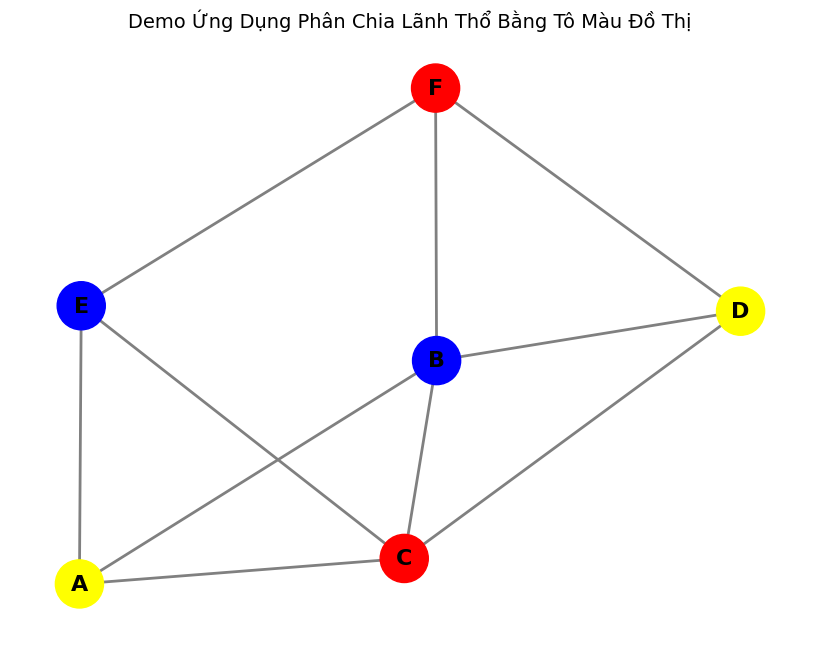

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Ma trận kề của đồ thị 6 đỉnh (Lãnh thổ gồm 6 khu vực A, B, C, D, E, F)
G_matrix = [
    [0, 1, 1, 0, 1, 0],  # A kề B, C, E
    [1, 0, 1, 1, 0, 1],  # B kề A, C, D, F
    [1, 1, 0, 1, 1, 0],  # C kề A, B, D, E
    [0, 1, 1, 0, 0, 1],  # D kề B, C, F
    [1, 0, 1, 0, 0, 1],  # E kề A, C, F
    [0, 1, 0, 1, 1, 0],  # F kề B, D, E
]

nodes = ["A", "B", "C", "D", "E", "F"]
palette = ["Blue", "Red", "Yellow", "Green"]

# 2. Tính bậc của các đỉnh (Số lượng hàng xóm)
degrees = {nodes[i]: sum(G_matrix[i]) for i in range(len(nodes))}

# 3. Sắp xếp các đỉnh theo thứ tự bậc giảm dần (Chiến lược Welch-Powell)
sorted_nodes = sorted(nodes, key=lambda x: degrees[x], reverse=True)

# 4. Thuật toán tô màu đồ thị
result_colors = {}  # Lưu kết quả: { 'Đỉnh': 'Màu' }

for node in sorted_nodes:
    # Lấy danh sách các màu mà các hàng xóm đã dùng
    node_index = nodes.index(node)
    neighbor_colors = []

    for neighbor_index, is_adjacent in enumerate(G_matrix[node_index]):
        if is_adjacent == 1:
            neighbor_node = nodes[neighbor_index]
            if neighbor_node in result_colors:
                neighbor_colors.append(result_colors[neighbor_node])

    # Chọn màu đầu tiên trong palette không bị trùng với hàng xóm
    for color in palette:
        if color not in neighbor_colors:
            result_colors[node] = color
            break

# 5. In kết quả ra màn hình console
print("--- KẾT QUẢ PHÂN CHIA LÃNH THỔ ---")
for node in sorted(result_colors.keys()):
    print(f"Khu vực {node} -> Tô màu: {result_colors[node]}")

# 6. Trực quan hóa bằng Đồ thị (Vẽ bản đồ dạng network)
G = nx.Graph()

# Thêm các cạnh dựa trên ma trận kề
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if G_matrix[i][j] == 1:
            G.add_edge(nodes[i], nodes[j])

# Lấy danh sách màu theo đúng thứ tự các đỉnh để vẽ
color_map = [result_colors[node] for node in G.nodes()]

# Tiến hành vẽ
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Định vị các đỉnh
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=1200,
    font_size=16,
    font_color="black",
    font_weight="bold",
    edge_color="gray",
    width=2,
)
plt.title("Demo Ứng Dụng Phân Chia Lãnh Thổ Bằng Tô Màu Đồ Thị", fontsize=14)
plt.show()